In [1]:
from pathlib import Path
from cheatgrass_model import ModelConfig, evaluate, discover_ids
import os, json

cfg = ModelConfig(
    data_dir=Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_data_quality_filtered_split/test"),
    output_dir=Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output"),
)

# Optional override: set environment variable CHEATGRASS_MODEL_PATH or assign MODEL_OVERRIDE below.
MODEL_OVERRIDE = os.getenv('CHEATGRASS_MODEL_PATH', None)  # e.g. '/path/to/model_best.pt' or set to a manifest file

def _find_latest_model_from_manifest(output_dir: Path) -> Path:
    manifests = sorted(output_dir.glob('run_*_manifest.json'), key=lambda p: p.stat().st_mtime, reverse=True)
    for m in manifests:
        try:
            obj = json.loads(m.read_text())
            bm = obj.get('best_model_path') or obj.get('best_model', None) or obj.get('best_model')
            if bm:
                p = Path(bm)
                if not p.exists():
                    # try relative to output_dir
                    p = output_dir / Path(bm).name
                if p.exists():
                    return p
        except Exception:
            continue
    return None

def _find_latest_model_file(output_dir: Path) -> Path:
    candidates = sorted(output_dir.glob('model_*_best.pt'), key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None

# Resolve model path (override -> manifest -> .pt file)
best_path = None
chosen_reason = None
if MODEL_OVERRIDE:
    best_path = Path(MODEL_OVERRIDE)
    chosen_reason = 'explicit override (CHEATGRASS_MODEL_PATH or MODEL_OVERRIDE)'
    if not best_path.exists():
        # If the override looks like a manifest file
        if best_path.name.endswith('_manifest.json'):
            try:
                bm = json.loads(best_path.read_text()).get('best_model_path')
                if bm: best_path = Path(bm)
            except Exception:
                pass

if best_path is None or not best_path.exists():
    # Try manifest
    best_path = _find_latest_model_from_manifest(cfg.output_dir)
    if best_path:
        chosen_reason = 'latest run manifest (best_model_path)'

if best_path is None or not best_path.exists():
    # Fallback to model_*_best.pt files
    best_path = _find_latest_model_file(cfg.output_dir)
    if best_path:
        chosen_reason = 'newest model_*_best.pt file in output_dir'

if best_path is None or not best_path.exists():
    raise FileNotFoundError(
        f'No model found in {cfg.output_dir}. Please set CHEATGRASS_MODEL_PATH env var or place a model in output_dir.'
    )

print(f"Selected model: {best_path}  (reason: {chosen_reason})")

# Set held_out_ids: you can replace with a specific list; default -> discover all ids under cfg.data_dir
held_out_ids = None  # replace list like ['12345','67890'] or None to auto-discover
if not held_out_ids:
    held_out_ids = discover_ids(cfg.data_dir)
    print(f"Auto-discovered {len(held_out_ids)} held-out ids under {cfg.data_dir} (first 10): {held_out_ids[:10]}")

results = evaluate(cfg, model_path=Path(best_path), test_ids=held_out_ids, threshold=0.5, crops_per_sample=3)
print('\n→ Test results: mean_dice =', results.get('mean_dice'), 'std_dice =', results.get('std_dice'))

Selected model: /home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output/model_balanced_spatially_robust_best.pt  (reason: latest run manifest (best_model_path))
Auto-discovered 13 held-out ids under /home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_data_quality_filtered_split/test (first 10): ['9709887', '9714675', '9716182', '9716386', '9726103', '9727007', '9728831', '9761370', '9761383', '9761395']


/home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_model.py:651: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=c

📊 Eval mean Dice=0.3675 (±0.3023)  -> eval_model_balanced_spatially_robust_best.json

→ Test results: mean_dice = 0.36751858016847533 std_dice = 0.30232686897278865


# OLD STUFF BELOW


In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import json
import random

# --- 1. ENHANCED CONFIGURATION ---
CONFIG = {
    'data_dir': Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_data_quality_filtered"),
    'output_dir': Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output"),
    'batch_size': 1,
    'learning_rate': 1e-4,
    'epochs': 50,
    'hidden_dim': 128,
    'input_bands': 6,
    'train_val_split_size': 0.2,
    'training_window_size': 32,
    'enable_augmentation': True,
    'validation_crops_per_sample': 3,  # Multiple random crops during validation too!
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}
CONFIG['output_dir'].mkdir(exist_ok=True)
print(f"Using device: {CONFIG['device']}")
print(f"Training window size: {CONFIG['training_window_size']}x{CONFIG['training_window_size']}")
print(f"FIXED: Validation will also use random cropping!")

# --- 2. ADVANCED LOSS FUNCTION (Focal Tversky) ---
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha, beta, gamma=1):
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Apply sigmoid to convert logits to probabilities
        inputs = torch.sigmoid(inputs)
        
        tp = (inputs * targets).sum()
        fp = ((1 - targets) * inputs).sum()
        fn = (targets * (1 - inputs)).sum()

        tversky = (tp) / (tp + self.alpha * fp + self.beta * fn + 1e-6)
        return (1 - tversky) ** self.gamma

# --- 3. ENHANCED RANDOM CROPPING ---
def load_sample_metadata(data_dir, sample_id):
    """Load metadata for a sample to determine its context size."""
    metadata_path = data_dir / f"{sample_id}_metadata.json"
    if metadata_path.exists():
        try:
            with open(metadata_path, 'r') as f:
                return json.load(f)
        except:
            pass
    return None

def find_valid_crop_position_enhanced(mask, crop_size, force_include_vegetation=True, min_mask_pixels=1):
    """
    Enhanced crop position finding with better spatial distribution.
    
    Args:
        mask: Input mask of shape (H, W)
        crop_size: Size of the crop window
        force_include_vegetation: If True, ensures vegetation is included
        min_mask_pixels: Minimum number of mask pixels required in crop
    
    Returns:
        (top, left) coordinates for cropping
    """
    h, w = mask.shape
    if h <= crop_size or w <= crop_size:
        return 0, 0
    
    # Find all positions where mask has pixels
    mask_positions = np.where(mask > 0)
    
    if len(mask_positions[0]) == 0 or not force_include_vegetation:
        # No mask pixels or not forcing inclusion - return truly random position
        top = random.randint(0, h - crop_size)
        left = random.randint(0, w - crop_size)
        return top, left
    
    # Strategy: Encourage vegetation to appear in different parts of the crop window
    max_attempts = 100
    valid_positions = []
    
    for attempt in range(max_attempts):
        # Choose a random mask pixel as anchor
        idx = random.randint(0, len(mask_positions[0]) - 1)
        anchor_y, anchor_x = mask_positions[0][idx], mask_positions[1][idx]
        
        # Randomly position the anchor in different parts of the crop window
        # This is key: don't always center the vegetation!
        if random.random() < 0.2:  # 20% chance: vegetation in top-left
            anchor_offset_y = random.randint(0, crop_size // 4)
            anchor_offset_x = random.randint(0, crop_size // 4)
        elif random.random() < 0.4:  # 20% chance: vegetation in top-right
            anchor_offset_y = random.randint(0, crop_size // 4)
            anchor_offset_x = random.randint(3 * crop_size // 4, crop_size - 1)
        elif random.random() < 0.6:  # 20% chance: vegetation in bottom-left
            anchor_offset_y = random.randint(3 * crop_size // 4, crop_size - 1)
            anchor_offset_x = random.randint(0, crop_size // 4)
        elif random.random() < 0.8:  # 20% chance: vegetation in bottom-right
            anchor_offset_y = random.randint(3 * crop_size // 4, crop_size - 1)
            anchor_offset_x = random.randint(3 * crop_size // 4, crop_size - 1)
        else:  # 20% chance: vegetation anywhere (including center)
            anchor_offset_y = random.randint(0, crop_size - 1)
            anchor_offset_x = random.randint(0, crop_size - 1)
        
        top = anchor_y - anchor_offset_y
        left = anchor_x - anchor_offset_x
        
        # Ensure crop is within bounds
        top = max(0, min(top, h - crop_size))
        left = max(0, min(left, w - crop_size))
        
        # Check if this crop has enough mask pixels
        crop_mask = mask[top:top+crop_size, left:left+crop_size]
        if np.sum(crop_mask) >= min_mask_pixels:
            valid_positions.append((top, left))
            
            # Early return if we have a good position
            if len(valid_positions) >= 5:
                break
    
    if valid_positions:
        return random.choice(valid_positions)
    
    # Fallback: random position that includes some vegetation
    for _ in range(20):
        top = random.randint(0, h - crop_size)
        left = random.randint(0, w - crop_size)
        crop_mask = mask[top:top+crop_size, left:left+crop_size]
        if np.sum(crop_mask) >= min_mask_pixels:
            return top, left
    
    # Final fallback: center crop
    top = (h - crop_size) // 2
    left = (w - crop_size) // 2
    return top, left

def enhanced_random_crop_sample(data, mask, crop_size, is_training=True, force_spatial_diversity=True):
    """
    Enhanced random cropping with true spatial diversity.
    """
    t, c, h, w = data.shape
    
    if h == crop_size and w == crop_size:
        return data, mask
    
    # Pad if needed
    if h < crop_size or w < crop_size:
        pad_h = max(0, crop_size - h)
        pad_w = max(0, crop_size - w)
        data = torch.nn.functional.pad(data, (0, pad_w, 0, pad_h), mode='constant', value=0)
        mask = torch.nn.functional.pad(mask, (0, pad_w, 0, pad_h), mode='constant', value=0)
        h, w = data.shape[2], data.shape[3]
    
    if is_training and h > crop_size and w > crop_size and force_spatial_diversity:
        # Use enhanced crop positioning
        first_mask = mask[0, 0].numpy() if isinstance(mask, torch.Tensor) else mask[0, 0]
        top, left = find_valid_crop_position_enhanced(first_mask, crop_size, force_include_vegetation=True)
    elif h > crop_size and w > crop_size:
        # Random cropping for validation (not center!)
        first_mask = mask[0, 0].numpy() if isinstance(mask, torch.Tensor) else mask[0, 0]
        top, left = find_valid_crop_position_enhanced(first_mask, crop_size, force_include_vegetation=True)
    else:
        # Center crop as last resort
        top = (h - crop_size) // 2
        left = (w - crop_size) // 2
    
    # Apply crop
    data_cropped = data[:, :, top:top+crop_size, left:left+crop_size]
    mask_cropped = mask[:, :, top:top+crop_size, left:left+crop_size]
    
    return data_cropped, mask_cropped

# --- 4. MODEL CLASSES ---
class PhenologyAwareUNet(nn.Module):
    def __init__(self, input_bands=6, hidden_dim=128, output_classes=1):
        super(PhenologyAwareUNet, self).__init__()
        # CNN to extract features from each time step
        self.feature_cnn = nn.Sequential(
            nn.Conv2d(input_bands, 32, kernel_size=3, stride=1, padding=0), nn.ReLU(True), # 32x32 -> 30x30
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0), nn.ReLU(True), # 30x30 -> 28x28
            nn.MaxPool2d(kernel_size=2, stride=2) # 28x28 -> 14x14
        )
        
        # Feature size after CNN and flattening
        fs = 64 * 14 * 14 # 12544
        
        # LSTM to process the sequence of features
        self.lstm = nn.LSTM(fs, hidden_dim, batch_first=True, bidirectional=True)
        
        # Linear layer to project LSTM output back to feature map size for decoder
        self.projection = nn.Linear(hidden_dim * 2, fs) # hidden_dim * 2 for bidirectional LSTM
        
        # Decoder to reconstruct the segmentation mask
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), # 14x14 -> 14x14
            nn.ReLU(True),
            # Use ConvTranspose2d for proper upsampling
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 14x14 -> 28x28
            nn.ReLU(True),
            # Get back to 32x32
            nn.ConvTranspose2d(32, 32, kernel_size=5, stride=1, padding=0), # 28x28 -> 32x32
            nn.ReLU(True),
            nn.Conv2d(32, output_classes, kernel_size=1) # Final output layer
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        
        if h != 32 or w != 32:
            raise ValueError(f"Model expects 32x32 input, got {h}x{w}")
        
        # Process each time step through the CNN
        cnn_outputs = []
        for i in range(t):
            cnn_out = self.feature_cnn(x[:, i])
            cnn_outputs.append(cnn_out.flatten(1))
        
        # Stack CNN outputs for LSTM
        cnn_out = torch.stack(cnn_outputs, 1)
        
        # Pass through LSTM
        lstm_out, _ = self.lstm(cnn_out)

        # Project LSTM output back to CNN feature map size and reshape for decoder
        decoder_outputs = []
        for i in range(t):
            projected = self.projection(lstm_out[:, i]).view(b, 64, 14, 14)
            decoded = self.decoder(projected)
            decoder_outputs.append(decoded)
        
        return torch.stack(decoder_outputs, 1)

# --- 5. SPATIALLY ROBUST DATASET CLASS ---
class SpatiallyRobustVeduDataset(Dataset):
    def __init__(self, data_dir, location_ids, training_window_size=32, is_training=True, 
                 enable_augmentation=True, crops_per_epoch=1):
        self.data_dir = Path(data_dir)
        self.location_ids = [str(gid) for gid in location_ids]
        self.training_window_size = training_window_size
        self.is_training = is_training
        self.enable_augmentation = enable_augmentation
        self.crops_per_epoch = crops_per_epoch
        self.current_epoch = 0  # Initialize current epoch
        
        # Load metadata for each sample
        self.sample_metadata = {}
        for loc_id in self.location_ids:
            metadata = load_sample_metadata(self.data_dir, loc_id)
            self.sample_metadata[loc_id] = metadata
    
    def set_epoch(self, epoch):
        """Set the current epoch for epoch-dependent randomization."""
        self.current_epoch = epoch
    
    def __len__(self): 
        return len(self.location_ids) * self.crops_per_epoch
    
    def __getitem__(self, idx):
        # Add epoch-based randomization to ensure different crops each epoch
        random.seed(idx + self.current_epoch * 42)
        
        # Map linear index to (sample_idx, crop_idx)
        sample_idx = idx // self.crops_per_epoch
        crop_idx = idx % self.crops_per_epoch
        
        loc_id = self.location_ids[sample_idx]
        
        # Load data and target
        data = np.load(self.data_dir / f"{loc_id}_data.npy").astype(np.float32)
        target = np.load(self.data_dir / f"{loc_id}_mask.npy").astype(np.float32)
        
        # Data comes as (T, H, W, C) - transpose to (T, C, H, W)
        data = np.transpose(data, (0, 3, 1, 2))
        
        # Target comes as (T, H, W) - add channel dimension to get (T, 1, H, W)
        if target.ndim == 3:  # (T, H, W)
            target = np.expand_dims(target, axis=1)  # (T, 1, H, W)
        elif target.ndim == 2:  # (H, W) - single time step
            target = np.expand_dims(target, axis=0)  # (1, H, W)
            target = np.expand_dims(target, axis=1)  # (1, 1, H, W)
        
        # Convert to tensors
        data = torch.from_numpy(data)
        target = torch.from_numpy(target)
        
        # Apply enhanced random cropping
        if self.enable_augmentation:
            data, target = enhanced_random_crop_sample(
                data, target, 
                self.training_window_size, 
                is_training=self.is_training,
                force_spatial_diversity=True
            )
        else:
            # Even without augmentation, avoid center cropping
            if data.shape[2] != self.training_window_size or data.shape[3] != self.training_window_size:
                data, target = enhanced_random_crop_sample(
                    data, target, 
                    self.training_window_size, 
                    is_training=False,
                    force_spatial_diversity=False
                )
        
        return data, target

# --- 6. ENHANCED TRAINING FUNCTION ---
def train_spatially_robust_experiment(exp_name, train_ids, val_ids, config, alpha, beta):
    print(f"\n{'='*60}")
    print(f"STARTING SPATIALLY ROBUST EXPERIMENT: {exp_name}")
    print(f"Train samples: {len(train_ids)}, Validation samples: {len(val_ids)}")
    print(f"Alpha: {alpha}, Beta: {beta}")
    print(f"Validation crops per sample: {config['validation_crops_per_sample']}")
    print(f"{'='*60}")
    
    # Training dataset - multiple crops per sample per epoch
    train_dataset = SpatiallyRobustVeduDataset(
        config['data_dir'], train_ids, 
        training_window_size=config['training_window_size'],
        is_training=True,
        enable_augmentation=config['enable_augmentation'],
        crops_per_epoch=3  # 3 different crops per sample per epoch
    )
    
    # Validation dataset - multiple crops per sample for robust validation
    val_dataset = SpatiallyRobustVeduDataset(
        config['data_dir'], val_ids,
        training_window_size=config['training_window_size'],
        is_training=True,  # Still use random cropping for validation!
        enable_augmentation=True,  # Enable augmentation for validation too!
        crops_per_epoch=config['validation_crops_per_sample']
    )
    
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    model = PhenologyAwareUNet(input_bands=config['input_bands'], 
                              hidden_dim=config['hidden_dim'], 
                              output_classes=1).to(config['device'])
    
    criterion = FocalTverskyLoss(alpha=alpha, beta=beta)
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    best_val_loss = float('inf')

    train_losses = []
    val_losses = []

    for epoch in range(config['epochs']):
        # Set epoch for both datasets to ensure different random crops
        train_dataset.set_epoch(epoch)
        val_dataset.set_epoch(epoch)
        
        # Training phase
        model.train()
        epoch_train_loss = 0
        train_batches = 0
        val_losses_per_batch = []
        
        for data, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']} Train", leave=False):
            data, target = data.to(config['device']), target.to(config['device'])
            optimizer.zero_grad()
            
            model_output = model(data)
            loss = criterion(model_output.flatten(), target.flatten())
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            train_batches += 1
        
        avg_train_loss = epoch_train_loss / train_batches if train_batches > 0 else 0
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0
        val_batches = 0
        
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(val_loader):
                data, target = data.to(config['device']), target.to(config['device'])
                model_output = model(data)
                loss = criterion(model_output.flatten(), target.flatten())
                val_losses_per_batch.append(loss.item())
                epoch_val_loss += loss.item()
                val_batches += 1
                
                # Debug: Print first few batches
                if batch_idx < 3 and epoch < 3:  # Only first 3 epochs, first 3 batches
                    print(f"    Val batch {batch_idx}: loss={loss.item():.6f}, "
                          f"pred_range=[{model_output.min():.3f}, {model_output.max():.3f}], "
                          f"target_sum={target.sum().item()}")
        
        avg_val_loss = epoch_val_loss / val_batches if val_batches > 0 else 0
        
        # Print validation loss distribution for first few epochs
        if epoch < 3:
            print(f"    Val loss std: {np.std(val_losses_per_batch):.6f}")
            print(f"    Val loss range: [{min(val_losses_per_batch):.6f}, {max(val_losses_per_batch):.6f}]")
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), config['output_dir'] / f"model_{exp_name}_spatially_robust_best.pt")
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    print(f"✅ Spatially robust experiment {exp_name} completed. Best Val Loss: {best_val_loss:.4f}")
    
    # Save training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Spatially Robust Training Curves - {exp_name}')
    plt.legend()
    plt.grid(True)
    plt.savefig(config['output_dir'] / f"spatially_robust_training_curves_{exp_name}.png")
    plt.close()
    
    return {'experiment': exp_name, 'best_val_loss': best_val_loss}

# --- 7. MAIN EXECUTION ---


Using device: cuda
Training window size: 32x32
FIXED: Validation will also use random cropping!


In [9]:
MODEL_NAME = "balanced_spatially_robust"
results_df = evaluate_model_to_csv(MODEL_NAME, CONFIG, threshold=0.5)
results_df.head()


/tmp/ipykernel_977058/2398322410.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=config['device']))


✅ Wrote results: /home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output/balanced_spatially_robust_detailed_results.csv (n=4)


,sample_idx,gid,dice,precision,recall,gt_pixels,pred_pixels,max_prob
0,0,5D9E26B4-C8DD-4527-9B3C-F71CC0164729,0.117187,0.062241,1.000000,420,6748,1.0
1,1,9D576000-945F-4D7E-95D1-4345FE86A0D4,0.071417,0.037338,0.818182,264,5785,1.0
2,2,DD05AB51-695A-49A3-B4BF-939178688AFD,0.320513,0.207469,0.704225,2201,7471,1.0
3,3,None,0.074534,0.044850,0.220408,490,2408,1.0


In [10]:
from pathlib import Path
out = Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output")
print("Model files:", list(out.glob("model_*best.pt")))
print("Result CSVs:", list(out.glob("*_detailed_results.csv")))





Model files: [PosixPath('/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output/model_balanced_spatially_robust_spatially_robust_best.pt')]
Result CSVs: [PosixPath('/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output/balanced_spatially_robust_detailed_results.csv')]


📄 Using existing results: /home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output/balanced_spatially_robust_detailed_results.csv (n=4)
Found 4 id(s) in data_dir: /home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_data_quality_filtered


/tmp/ipykernel_977058/515879624.py:170: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=CONFIG['device']))


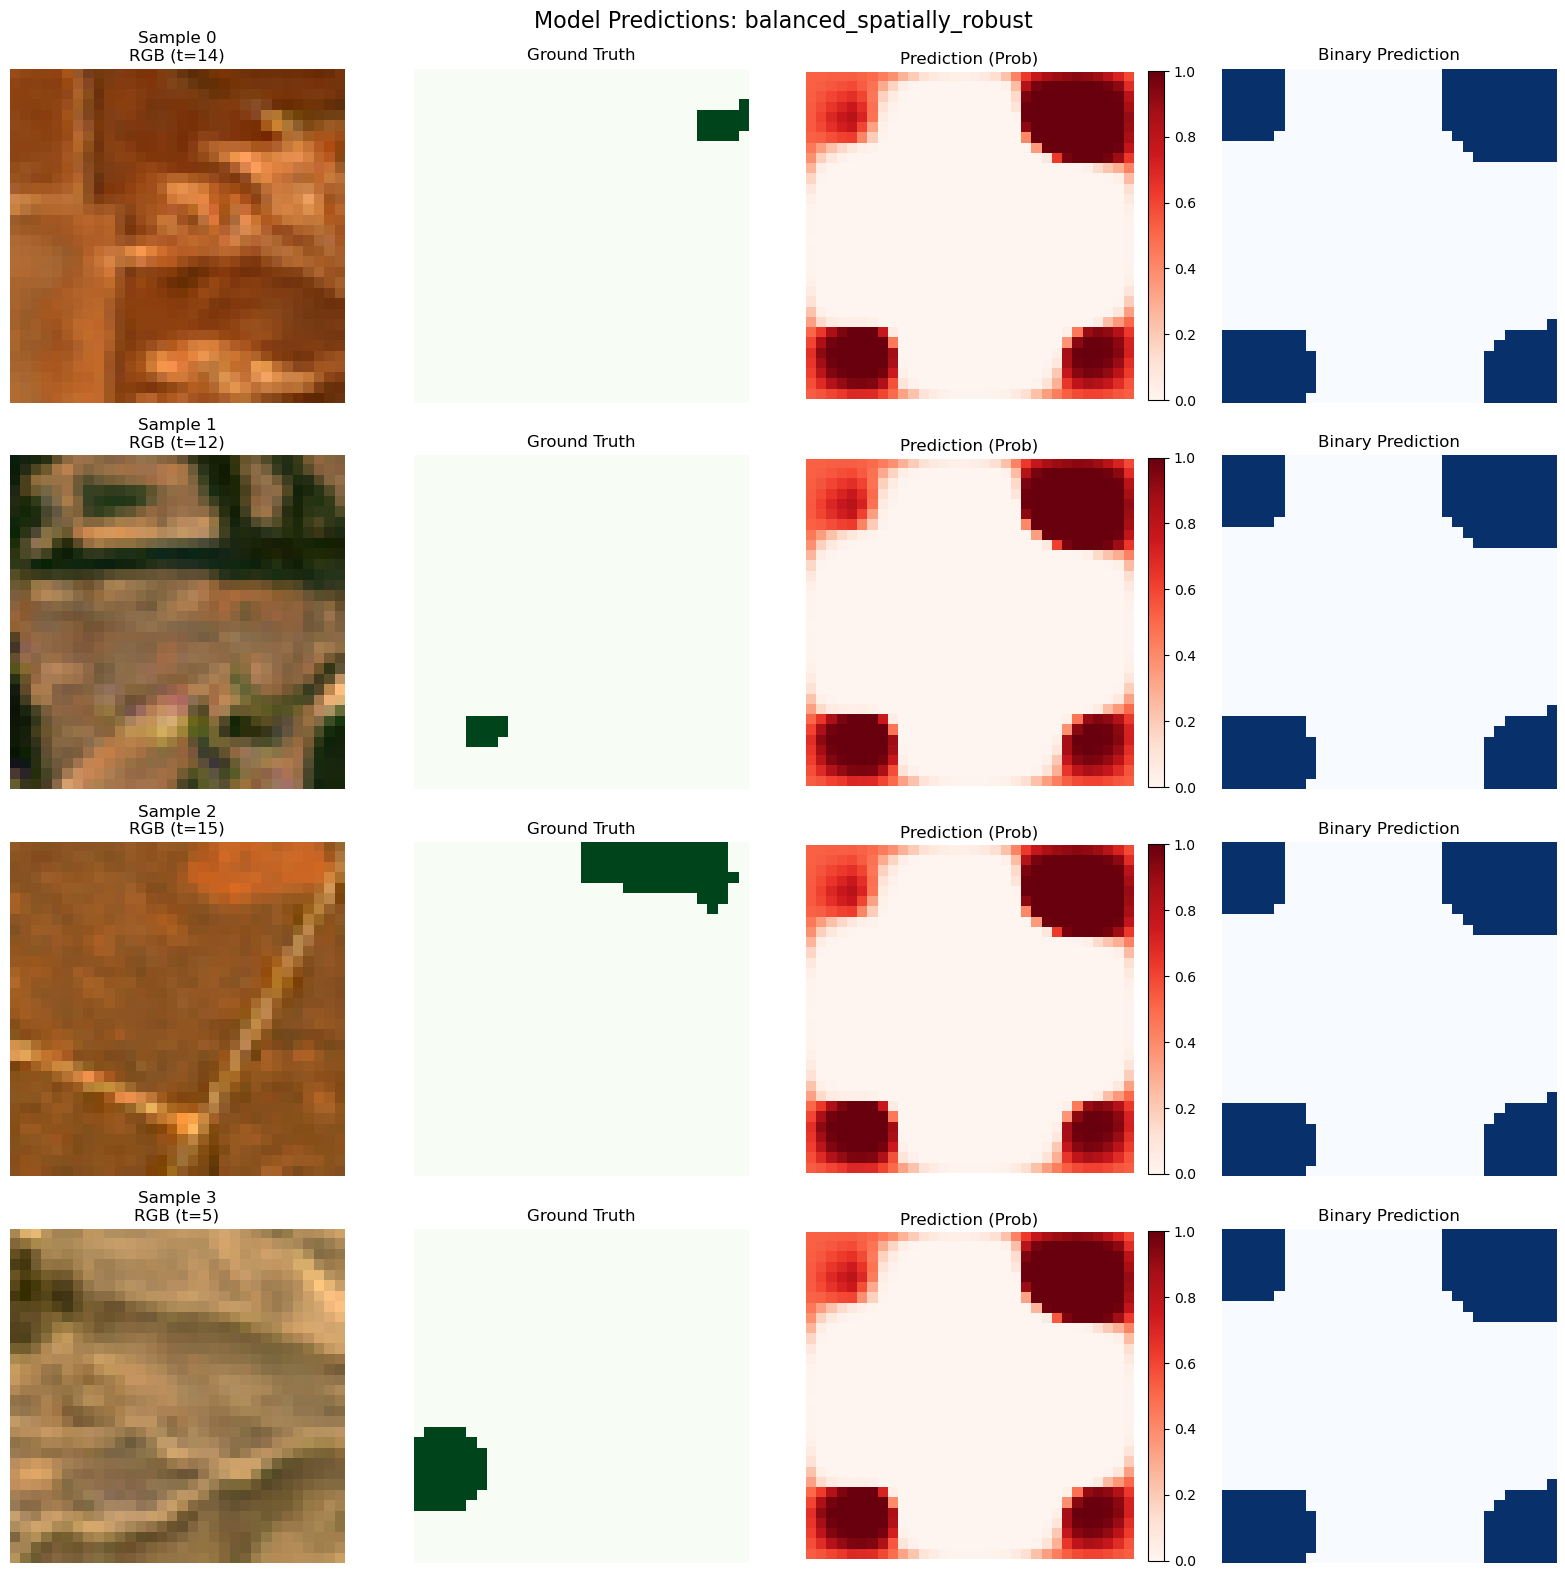

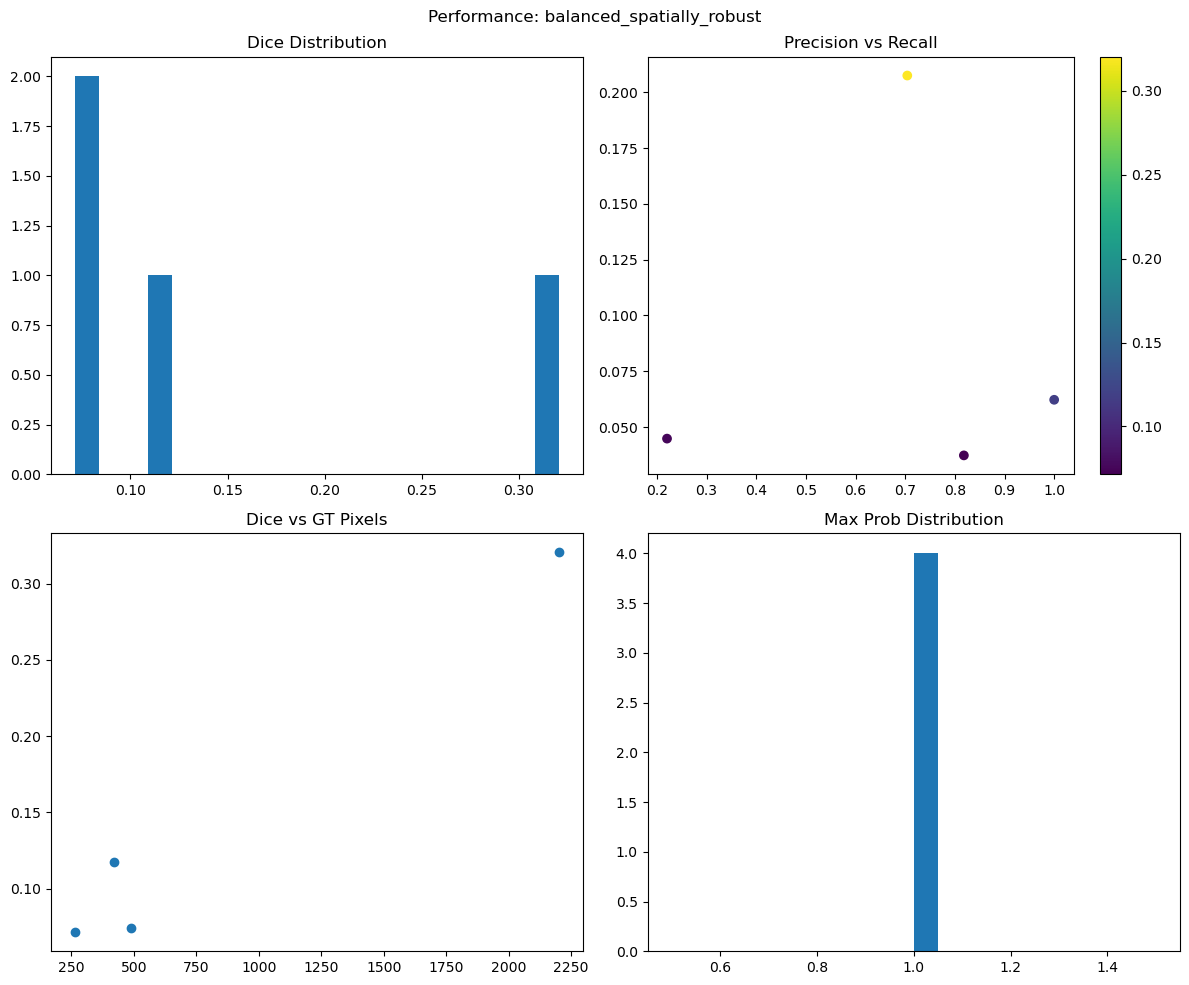

: 

In [ ]:
# === Unified evaluation + visualization (matches your training) ===
import torch, numpy as np, pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- CONFIG: use the SAME dirs you trained/evaluated with ---
CONFIG = {
    'data_dir': Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_data_quality_filtered"),
    'output_dir': Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/model1_output"),
    'batch_size': 1,
    'input_bands': 6,
    'hidden_dim': 128,
    'training_window_size': 32,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}
MODEL_NAME = "balanced_spatially_robust"  # => model_balanced_spatially_robust_spatially_robust_best.pt
THRESHOLD = 0.5

EPS = 1e-7

def discover_ids(data_dir: Path):
    data_ids = {p.stem.replace("_data", "") for p in data_dir.glob("*_data.npy")}
    mask_ids = {p.stem.replace("_mask", "") for p in data_dir.glob("*_mask.npy")}
    ids = sorted(list(data_ids & mask_ids))
    return ids

def make_test_loader(ids, config):
    ds = SpatiallyRobustVeduDataset(
        config['data_dir'], ids,
        training_window_size=config['training_window_size'],
        is_training=False, enable_augmentation=False, crops_per_epoch=1
    )
    return DataLoader(ds, batch_size=config['batch_size'], shuffle=False)

def binarize_probs(p, thr=0.5): return (p > thr).float()

def compute_metrics(pred_bin, target_bin):
    p = pred_bin.view(-1); t = target_bin.view(-1)
    tp = (p * t).sum().item()
    fp = (p * (1 - t)).sum().item()
    fn = ((1 - p) * t).sum().item()
    dice = (2.0 * tp) / (2.0 * tp + fp + fn + EPS)
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    return dice, precision, recall, tp, fp, fn

def evaluate_model_to_csv(model_name: str, config, threshold=0.5):
    ckpt = config['output_dir'] / f"model_{model_name}_spatially_robust_best.pt"
    if not ckpt.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt}")

    ids = discover_ids(config['data_dir'])
    if not ids:
        raise RuntimeError(f"No *_data.npy/_mask.npy pairs in {config['data_dir']}")
    loader = make_test_loader(ids, config)

    model = PhenologyAwareUNet(
        input_bands=config['input_bands'], hidden_dim=config['hidden_dim'], output_classes=1
    ).to(config['device'])
    model.load_state_dict(torch.load(ckpt, map_location=config['device']))
    model.eval()  # switch to eval behavior (BatchNorm/Dropout). See docs. :contentReference[oaicite:0]{index=0}

    rows = []
    with torch.no_grad():     # disable autograd for inference. :contentReference[oaicite:1]{index=1}
        for idx, (data, target) in enumerate(loader):
            data, target = data.to(config['device']), target.to(config['device'])
            logits = model(data)               # (B=1,T,1,32,32)
            probs  = torch.sigmoid(logits)
            pred_b = binarize_probs(probs, thr=threshold)

            dice, prec, rec, tp, fp, fn = compute_metrics(pred_b, target)
            rows.append(dict(
                sample_idx=idx,
                gid=discover_ids(config['data_dir'])[idx] if idx < len(discover_ids(config['data_dir'])) else f"idx_{idx}",
                dice=dice, precision=prec, recall=rec,
                gt_pixels=int(target.sum().item()),
                pred_pixels=int(pred_b.sum().item()),
                max_prob=float(probs.max().item())
            ))

    df = pd.DataFrame(rows)
    out_csv = config['output_dir'] / f"{model_name}_detailed_results.csv"
    df.to_csv(out_csv, index=False)
    print(f"✅ Wrote results: {out_csv} (n={len(df)})")
    return df

# --- simple visualizations (middle time step view + distributions) ---
def create_prediction_visualization(model, test_loader, results_df, model_name, config, num_samples=4, save_path=None):
    model.eval()
    # pick top/bottom/median if available
    take = min(num_samples, len(results_df))
    sel = pd.concat([
        results_df.sort_values('dice', ascending=False).head(take//2),
        results_df.sort_values('dice', ascending=True).head(take - take//2)
    ]).drop_duplicates('sample_idx').head(take)
    wanted = set(sel['sample_idx'].tolist())

    samples = []
    with torch.no_grad():
        for idx, (data, target) in enumerate(test_loader):
            if idx not in wanted: continue
            data, target = data.to(config['device']), target.to(config['device'])
            out = model(data)
            prob = torch.sigmoid(out)
            binp = (prob > THRESHOLD).float()

            samples.append(dict(
                idx=idx,
                data=data.cpu().numpy()[0],
                target=target.cpu().numpy()[0],
                prob=prob.cpu().numpy()[0],
                binp=binp.cpu().numpy()[0],
                metrics=results_df[results_df['sample_idx']==idx].iloc[0]
            ))
            if len(samples) >= take: break

    if not samples:
        print("Nothing to visualize."); return None

    import numpy as np
    fig, axes = plt.subplots(len(samples), 4, figsize=(16, 4*len(samples)))
    if len(samples) == 1: axes = axes.reshape(1, -1)

    for i, s in enumerate(samples):
        data, target, prob, binp = s['data'], s['target'], s['prob'], s['binp']
        mid = data.shape[0]//2
        rgb_bands = [2,1,0] if data.shape[1] >= 3 else [0,0,0]
        rgb = data[mid, rgb_bands].transpose(1,2,0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        axes[i,0].imshow(rgb); axes[i,0].set_title(f'Sample {s["idx"]}\nRGB (t={mid})'); axes[i,0].axis('off')
        axes[i,1].imshow(target[mid,0], cmap='Greens', vmin=0, vmax=1); axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
        im=axes[i,2].imshow(prob[mid,0], cmap='Reds', vmin=0, vmax=1); axes[i,2].set_title('Prediction (Prob)'); axes[i,2].axis('off'); plt.colorbar(im, ax=axes[i,2], fraction=0.046, pad=0.04)
        axes[i,3].imshow(binp[mid,0], cmap='Blues', vmin=0, vmax=1); axes[i,3].set_title('Binary Prediction'); axes[i,3].axis('off')

    plt.suptitle(f'Model Predictions: {model_name}', fontsize=16)
    plt.tight_layout(); 
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

def create_performance_distribution_plot(results_df, model_name, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    axes[0,0].hist(results_df['dice'], bins=20); axes[0,0].set_title('Dice Distribution')
    sc = axes[0,1].scatter(results_df['recall'], results_df['precision'], c=results_df['dice']); axes[0,1].set_title('Precision vs Recall'); plt.colorbar(sc, ax=axes[0,1])
    axes[1,0].scatter(results_df['gt_pixels'], results_df['dice']); axes[1,0].set_title('Dice vs GT Pixels')
    axes[1,1].hist(results_df['max_prob'], bins=20); axes[1,1].set_title('Max Prob Distribution')
    plt.suptitle(f'Performance: {model_name}'); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); 
    return fig

# --- run: evaluate if needed, then visualize ---
csv_path = CONFIG['output_dir'] / f"{MODEL_NAME}_detailed_results.csv"
if not csv_path.exists():
    results_df = evaluate_model_to_csv(MODEL_NAME, CONFIG, threshold=THRESHOLD)
else:
    results_df = pd.read_csv(csv_path)
    print(f"📄 Using existing results: {csv_path} (n={len(results_df)})")

# Build loader over ALL ids in the folder
ids_all = discover_ids(CONFIG['data_dir'])
print(f"Found {len(ids_all)} id(s) in data_dir: {CONFIG['data_dir']}")
test_loader = make_test_loader(ids_all, CONFIG)

# Load model and make plots
ckpt = CONFIG['output_dir'] / f"model_{MODEL_NAME}_spatially_robust_best.pt"
model = PhenologyAwareUNet(CONFIG['input_bands'], CONFIG['hidden_dim'], 1).to(CONFIG['device'])
model.load_state_dict(torch.load(ckpt, map_location=CONFIG['device']))
model.eval()  # eval mode. :contentReference[oaicite:2]{index=2}

_ = create_prediction_visualization(
    model, test_loader, results_df, MODEL_NAME, CONFIG,
    num_samples=min(6, len(results_df)),
    save_path=CONFIG['output_dir'] / f'{MODEL_NAME}_predictions.png'
)
_ = create_performance_distribution_plot(
    results_df, MODEL_NAME,
    save_path=CONFIG['output_dir'] / f'{MODEL_NAME}_performance.png'
)


In [2]:
# Ensure we're using the updated cheatgrass_model module and guard evaluate() JSON dump
import importlib, cheatgrass_model, json as _json
importlib.reload(cheatgrass_model)  # pick up latest changes without restarting kernel
from cheatgrass_model import evaluate, make_json_safe, _json_default

print('cheatgrass_model reloaded from:', cheatgrass_model.__file__)

# Temporarily patch the module json.dump to ensure safe serialization in this kernel
orig_dump = cheatgrass_model.json.dump
def _safe_dump(obj, fp, **kwargs):
    return orig_dump(make_json_safe(obj), fp, default=_json_default, **kwargs)
cheatgrass_model.json.dump = _safe_dump

try:
    # call evaluate and it will write JSON using patched dump
    results = evaluate(cfg, model_path=Path(best_path), test_ids=held_out_ids, threshold=0.5, crops_per_sample=3)
    print('\n→ Test results: mean_dice =', results.get('mean_dice'), 'std_dice =', results.get('std_dice'))
except TypeError as e:
    # Print helpful debug info if something is still not serializable
    print('TypeError during evaluate:', e)
    import traceback, sys
    traceback.print_exc()
    # Try to call evaluate again (it should be fine because of patched dump)
    try:
        results = evaluate(cfg, model_path=Path(best_path), test_ids=held_out_ids, threshold=0.5, crops_per_sample=3)
        print('\n→ Test results (2):', results.get('mean_dice'), results.get('std_dice'))
    except Exception as e2:
        print('Second attempt failed:', e2)
finally:
    # restore original dump function
    cheatgrass_model.json.dump = orig_dump

cheatgrass_model reloaded from: /home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_model.py


Testing: 100%|██████████| 39/39 [00:00<00:00, 110.81it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_2110654/3541706328.py", line 16, in <module>
    results = evaluate(cfg, model_path=Path(best_path), test_ids=held_out_ids, threshold=0.5, crops_per_sample=3)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/rbielski/miniconda3/envs/geo_env/lib/python3.11/site-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/rbielski/SAL_Git_Projects/Cheatgrass/cheatgrass_model.py", line 696, in evaluate
    json.dump(safe_results, f, indent=2, default=_json_default)
  File "/tmp/ipykernel_2110654/3541706328.py", line 11, in _safe_dump
    return orig_dump(make_json_safe(obj), fp, default=_json_default, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: json.dump() 

TypeError during evaluate: json.dump() got multiple values for keyword argument 'default'


Testing: 100%|██████████| 39/39 [00:00<00:00, 109.68it/s]

Second attempt failed: 'default'


In [3]:
# --- Visualize evaluation results (json/csv) + top/bottom sample preview
import json, numpy as np, matplotlib.pyplot as plt, pandas as pd, torch
from pathlib import Path
from cheatgrass_model import PhenologyAwareUNet, SpatiallyRobustVeduDataset
from torch.utils.data import DataLoader

out_json = cfg.output_dir / f"eval_{Path(best_path).stem}.json"
if not out_json.exists():
    print('No eval JSON found at', out_json); raise SystemExit('Run evaluate() first or check output_dir')

res = json.loads(out_json.read_text())
per_dice = np.array(res.get('per_batch_dice', []))
print('Eval JSON:', out_json.name, 'n_batches=', res.get('n_batches'), 'mean=', res.get('mean_dice'))

plt.figure(figsize=(6,4))
plt.hist(per_dice, bins=20, color='tab:blue', edgecolor='k')
plt.title('Per-batch Dice Distribution')
plt.xlabel('Dice'); plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10,3))
plt.plot(per_dice, 'o-', ms=4, alpha=0.75)
plt.title('Per-batch Dice (by batch index)')
plt.xlabel('Batch index'); plt.ylabel('Dice')
plt.grid(True); plt.show()

# If a detailed results CSV exists, use it to show per-sample metrics
csvs = sorted(cfg.output_dir.glob('*_detailed_results.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
if csvs:
    csv_path = csvs[0]
    df = pd.read_csv(csv_path)
    print('\nLoaded CSV:', csv_path.name, 'n=', len(df))

    if 'dice' in df.columns and 'gt_pixels' in df.columns:
        plt.figure(figsize=(6,4))
        plt.scatter(df['gt_pixels'], df['dice'], c=df['dice'], cmap='viridis', s=30)
        plt.colorbar(label='dice'); plt.xlabel('GT pixels'); plt.ylabel('Dice')
        plt.title('Dice vs GT pixels'); plt.grid(True); plt.show()

    # Show top/bottom 6 samples in the CSV
    topN = df.nlargest(6, 'dice') if 'dice' in df.columns else df.head(6)
    botN = df.nsmallest(6, 'dice') if 'dice' in df.columns else df.tail(6)
    print('\nTop 6 samples by Dice (CSV):')
    cols = [c for c in ['sample_idx','gid','dice','precision','recall','gt_pixels','pred_pixels'] if c in df.columns]
    print(topN[cols].to_string(index=False))
    print('\nBottom 6 samples by Dice (CSV):')
    print(botN[cols].to_string(index=False))

    # Try to visualize top/bottom examples using the model + dataset if possible
    try:
        print('\nAttempting to visualize top/bottom samples using the test loader & model...')
        # Build a simple test loader over the held_out_ids used in evaluate()
        if 'held_out_ids' not in globals():
            print('held_out_ids variable not present in kernel; skipping sample preview')
        else:
            ds = SpatiallyRobustVeduDataset(cfg.data_dir, held_out_ids, training_window_size=cfg.training_window_size, is_training=False, enable_augmentation=False, crops_per_epoch=1)
            loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False)
            model = PhenologyAwareUNet(cfg.input_bands, cfg.hidden_dim, 1).to(cfg.device)
            model.load_state_dict(torch.load(best_path, map_location=cfg.device))
            model.eval()

            # collect selected sample indices
            selected_idx = set()
            if 'sample_idx' in topN.columns: selected_idx.update(topN['sample_idx'].astype(int).tolist())
            if 'sample_idx' in botN.columns: selected_idx.update(botN['sample_idx'].astype(int).tolist())

            # Fallback: if sample_idx isn't in CSV, use top/bot by ordering
            if not selected_idx:
                selected_idx.update([0,1,2])

            examples = []
            with torch.no_grad():
                for idx, (data, target) in enumerate(loader):
                    if idx not in selected_idx: continue
                    data, target = data.to(cfg.device), target.to(cfg.device)
                    out = model(data); prob = torch.sigmoid(out); pred = (prob > 0.5).float()
                    examples.append(dict(idx=idx, data=data.cpu().numpy()[0], target=target.cpu().numpy()[0], prob=prob.cpu().numpy()[0], pred=pred.cpu().numpy()[0]))
                    if len(examples) >= len(selected_idx): break

            if examples:
                n = len(examples); fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
                if n == 1: axes = axes.reshape(1, 4)
                for i, s in enumerate(examples):
                    data = s['data']; target = s['target']; prob = s['prob']; pred = s['pred']
                    mid = data.shape[0] // 2
                    rgb_bands = [2,1,0] if data.shape[1] >= 3 else [0,0,0]
                    rgb = data[mid, rgb_bands].transpose(1,2,0)
                    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
                    axes[i,0].imshow(rgb); axes[i,0].axis('off'); axes[i,0].set_title(f'Sample {s["idx"]} RGB')
                    axes[i,1].imshow(target[mid,0], cmap='Greens', vmin=0, vmax=1); axes[i,1].axis('off'); axes[i,1].set_title('GT')
                    im = axes[i,2].imshow(prob[mid,0], cmap='Reds', vmin=0, vmax=1); axes[i,2].axis('off'); axes[i,2].set_title('Prob')
                    fig.colorbar(im, ax=axes[i,2], fraction=0.046, pad=0.04)
                    axes[i,3].imshow(pred[mid,0], cmap='Blues', vmin=0, vmax=1); axes[i,3].axis('off'); axes[i,3].set_title('Bin')
                plt.tight_layout(); plt.show()
            else:
                print('No examples collected; check test loader / held_out_ids')
    except Exception as e:
        print('Could not render sample previews (error):', e)
else:
    print('No detailed CSV found in output_dir; skipping CSV-based plots (run evaluate_model_to_csv first if you want per-sample info)')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)